## Artificial Neural Networks
Artificial Neural Networks (ANNs) are computer systems designed to mimic how the human brain processes information. Just like the brain uses neurons to process data and make decisions, ANNs use artificial neurons to analyze data, identify patterns and make predictions. These networks consist of layers of interconnected neurons that work together to solve complex problems. The key idea is that ANNs can "learn" from the data they process, just as our brain learns from experience. They are used in various applications from recognizing images to making personalized recommendations. In this article, we will see more about ANNs, how they function and other core concepts.

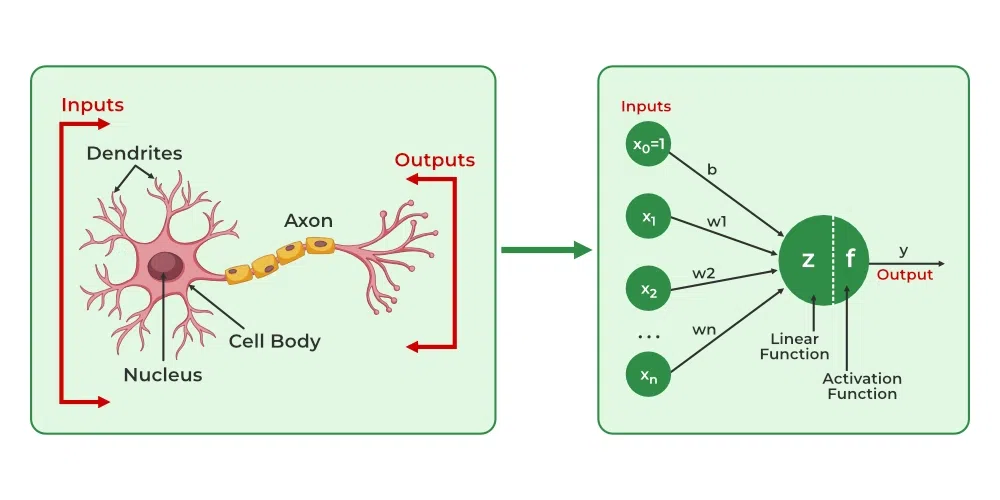

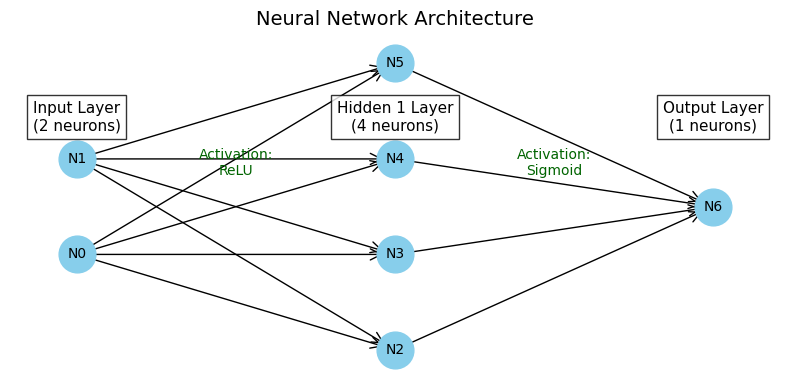

## Key Components of an ANN
Input Layer: This is where the network receives information. For example, in an image recognition task, the input could be an image.
Hidden Layers: These layers process the data received from the input layer. The more hidden layers there are, the more complex patterns the network can learn and understand. Each hidden layer transforms the data into more abstract information.
Output Layer: This is where the final decision or prediction is made. For example, after processing an image, the output layer might decide whether it’s a cat or a dog.

In [1]:
import numpy as np

## Initializing the Neural Network
Sets initial weights and biases for a two-layer neural network.
Uses np.random.seed(42) for reproducible results.
Weights (W1, W2) initialized with small random values scaled by 0.01 to avoid large initial weights.
W1 shape: (hidden layer size, input layer size).
W2 shape: (output layer size, hidden layer size).
Biases (b1, b2) initialized to zero vectors matching their layer sizes

In [2]:
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    parameters = {
        "W1": np.random.randn(hidden_size, input_size) * 0.01,
        "b1": np.zeros((hidden_size, 1)),
        "W2": np.random.randn(output_size, hidden_size) * 0.01,
        "b2": np.zeros((output_size, 1))
    }
    return parameters

## Defining Activation Functions
Activation functions introduce non-linearity into the model, helping it learn complex patterns. We here are using:

ReLU for the hidden layer
Sigmoid for the output layer.

In [3]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))


def relu(Z):
    return np.maximum(0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(int)

## Forward Propagation
In Forward propagation the function computes the output of the neural network for a given input X and parameters.

First, it calculates the linear combination Z1 for the hidden layer by multiplying the input X with the weights W1 and adding bias b1.
It then applies the ReLU activation function to Z1 producing the hidden layer activations A1.
Next, it calculates the linear combination Z2 for the output layer by multiplying A1 with W2 and adding b2.
The sigmoid activation function is applied to Z2 to produce the final output A2.
The function returns the output A2 along with a cache containing intermediate values needed for backpropagation.

In [4]:
def forward_propagation(X, parameters):
    W1, b1, W2, b2 = parameters["W1"], parameters["b1"], parameters["W2"], parameters["b2"]

    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

## Computing the Cost
Cost function calculates the binary cross-entropy loss which measures how well the neural network’s predictions A2 match the true labels Y.

m is the number of examples.
np.squeeze removes any extra dimensions, returning the cost as a scalar.

In [5]:
def compute_cost(Y, A2):
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2)) / m
    return np.squeeze(cost)

## Backpropagation
Backpropagation computes the gradients needed to update the network parameters during training.

It calculates the error at the output layer (dZ2) as the difference between predicted outputs (A2) and true labels (Y).
Using this error, it computes gradients of the weights (dW2) and biases (db2) for the output layer.
Then, it backpropagates the error to the hidden layer by multiplying with the transpose of W2 and element-wise with the derivative of the ReLU activation (relu_derivative).
Finally, it calculates gradients for the hidden layer weights (dW1) and biases (db1).
All gradients are averaged over the number of examples m to ensure stable updates.

In [6]:
def backward_propagation(X, Y, parameters, cache):
    m = X.shape[1]
    W2 = parameters["W2"]

    dZ2 = cache["A2"] - Y
    dW2 = np.dot(dZ2, cache["A1"].T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(cache["Z1"])
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

## Updating Parameters
Gradient descent updates the parameters using the computed gradients and a learning rate.

In [7]:
def update_parameters(parameters, grads, learning_rate):
    for key in parameters.keys():
        parameters[key] -= learning_rate * grads["d" + key]
    return parameters

## Training the Neural Network
We train the neural network over multiple iterations, updating parameters using backpropagation and gradient descent.

In [8]:
def train_neural_network(X, Y, input_size, hidden_size, output_size, epochs=1000, learning_rate=0.01):
    parameters = initialize_parameters(input_size, hidden_size, output_size)

    for i in range(epochs):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(Y, A2)
        grads = backward_propagation(X, Y, parameters, cache)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            print(f"Epoch {i}: Cost = {cost}")

    return parameters

## Making Predictions
The trained model predicts outputs by performing forward propagation and applying a threshold of 0.5.

In [9]:
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5).astype(int)

## Testing the Model
We test the model using an AND logic gate dataset.

In [10]:
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
Y = np.array([[0, 0, 0, 1]])

trained_parameters = train_neural_network(
    X, Y, input_size=2, hidden_size=4, output_size=1, epochs=10000, learning_rate=0.1)

predictions = predict(X, trained_parameters)
print("Predictions:", predictions)

Epoch 0: Cost = 0.693146369355556
Epoch 100: Cost = 0.5639151894233227
Epoch 200: Cost = 0.5565925189740488
Epoch 300: Cost = 0.4644741172097931
Epoch 400: Cost = 0.2951628061363734
Epoch 500: Cost = 0.15797766677307692
Epoch 600: Cost = 0.08563555993338258
Epoch 700: Cost = 0.0528825136510944
Epoch 800: Cost = 0.03704356618451611
Epoch 900: Cost = 0.029055833773090393
Epoch 1000: Cost = 0.02401034841169598
Epoch 1100: Cost = 0.020422312372831625
Epoch 1200: Cost = 0.017694655817974164
Epoch 1300: Cost = 0.015501749759281246
Epoch 1400: Cost = 0.013686620557187959
Epoch 1500: Cost = 0.01220429968875079
Epoch 1600: Cost = 0.01097423556257336
Epoch 1700: Cost = 0.009922426517793716
Epoch 1800: Cost = 0.009037597840418245
Epoch 1900: Cost = 0.008262495265921054
Epoch 2000: Cost = 0.007595727088792033
Epoch 2100: Cost = 0.007011782061884308
Epoch 2200: Cost = 0.006492342970863621
Epoch 2300: Cost = 0.006032762228198742
Epoch 2400: Cost = 0.005624169059161951
Epoch 2500: Cost = 0.0052600687